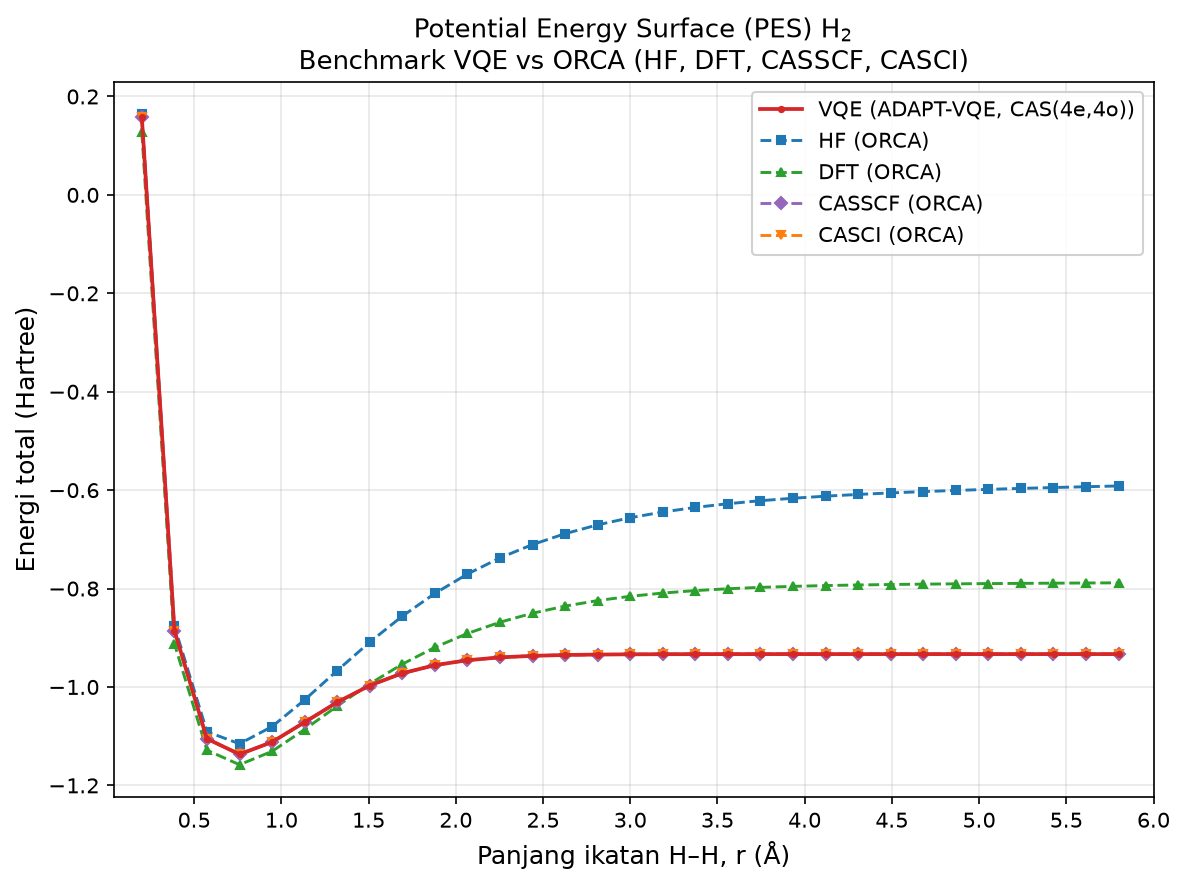

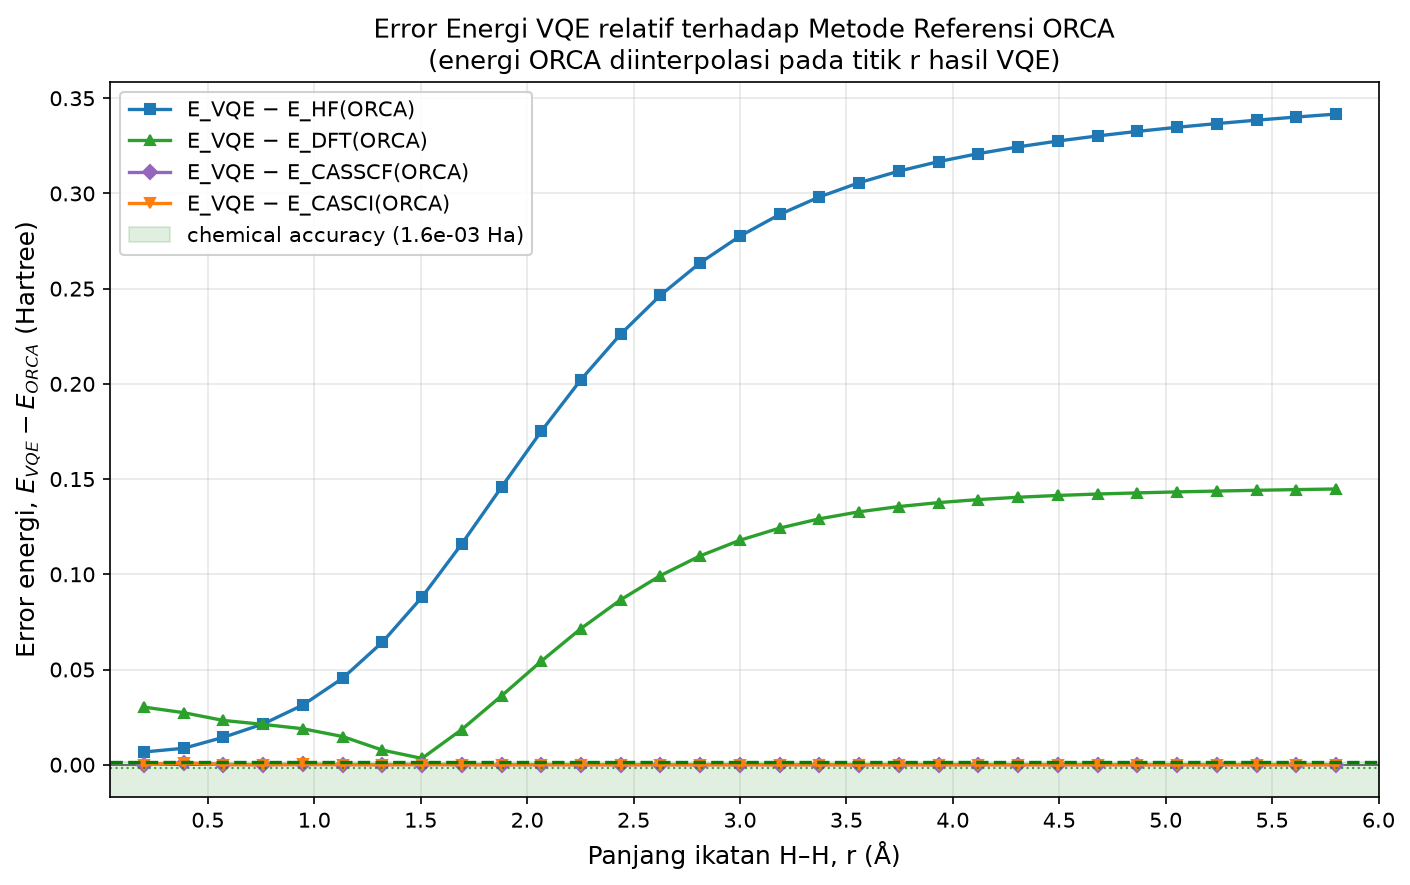

  r(Å)          ΔHF         ΔDFT      ΔCASSCF       ΔCASCI
  0.20   6.6929e-03   3.0260e-02   1.0000e-08   1.0000e-08
  0.39   8.6322e-03   2.7318e-02   8.8951e-04   8.8951e-04
  0.57   1.4396e-02   2.3249e-02   1.1099e-04   1.1099e-04
  0.76   2.1415e-02   2.1179e-02   0.0000e+00   0.0000e+00
  0.95   3.1311e-02   1.8896e-02   1.3702e-04   1.3702e-04
  1.13   4.5387e-02   1.4816e-02   7.3542e-05   7.3542e-05
  1.32   6.4342e-02   7.6729e-03   0.0000e+00   0.0000e+00
  1.51   8.8006e-02   3.3155e-03   1.0608e-04   1.0608e-04
  1.69   1.1596e-01   1.8488e-02   3.6175e-05   3.6175e-05
  1.88   1.4580e-01   3.6181e-02   0.0000e+00   0.0000e+00
  2.07   1.7502e-01   5.4306e-02   2.7148e-05   2.7148e-05
  2.25   2.0222e-01   7.1505e-02   7.4882e-06   7.4882e-06
  2.44   2.2617e-01   8.6645e-02   0.0000e+00   0.0000e+00
  2.63   2.4650e-01   9.9306e-02   4.4191e-06   4.4191e-06
  2.81   2.6356e-01   1.0967e-01   1.1406e-06   1.1406e-06
  3.00   2.7758e-01   1.1789e-01   0.0000e+00   0.0000e+

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# ----------------------------------------------------------------------
# 1. DATA (hasil ekstraksi dari file .out)
# ----------------------------------------------------------------------
data_evqe = [
    {"r": 0.200, "vqe": 0.15748213},
    {"r": 0.387, "vqe": -0.88552170},
    {"r": 0.573, "vqe": -1.10512817},
    {"r": 0.760, "vqe": -1.13679562},
    {"r": 0.946, "vqe": -1.11198863},
    {"r": 1.133, "vqe": -1.07168443},
    {"r": 1.320, "vqe": -1.03107267},
    {"r": 1.506, "vqe": -0.99708763},
    {"r": 1.693, "vqe": -0.97215107},
    {"r": 1.880, "vqe": -0.95568058},
    {"r": 2.066, "vqe": -0.94565818},
    {"r": 2.253, "vqe": -0.93990569},
    {"r": 2.440, "vqe": -0.93672674},
    {"r": 2.626, "vqe": -0.93501199},
    {"r": 2.813, "vqe": -0.93410391},
    {"r": 3.000, "vqe": -0.93363184},
    {"r": 3.187, "vqe": -0.93339159},
    {"r": 3.373, "vqe": -0.93327215},
    {"r": 3.560, "vqe": -0.93321419},
    {"r": 3.747, "vqe": -0.93318671},
    {"r": 3.933, "vqe": -0.93317397},
    {"r": 4.120, "vqe": -0.93316819},
    {"r": 4.307, "vqe": -0.93316561},
    {"r": 4.493, "vqe": -0.93316450},
    {"r": 4.680, "vqe": -0.93316402},
    {"r": 4.867, "vqe": -0.93316382},
    {"r": 5.053, "vqe": -0.93316375},
    {"r": 5.240, "vqe": -0.93316372},
    {"r": 5.427, "vqe": -0.93316371},
    {"r": 5.613, "vqe": -0.93316370},
    {"r": 5.800, "vqe": -0.93316370},
]

# ORCA HF: r (Å), E_HF (Ha)
data_hf = [
    {"r": 0.20000, "hf": 0.16417500},
    {"r": 0.38667, "hf": -0.87600656},
    {"r": 0.57333, "hf": -1.09083313},
    {"r": 0.76000, "hf": -1.11538066},
    {"r": 0.94667, "hf": -1.08049845},
    {"r": 1.13333, "hf": -1.02619512},
    {"r": 1.32000, "hf": -0.96673080},
    {"r": 1.50667, "hf": -0.90888134},
    {"r": 1.69333, "hf": -0.85610589},
    {"r": 1.88000, "hf": -0.80987709},
    {"r": 2.06667, "hf": -0.77050681},
    {"r": 2.25333, "hf": -0.73763499},
    {"r": 2.44000, "hf": -0.71055342},
    {"r": 2.62667, "hf": -0.68844240},
    {"r": 2.81333, "hf": -0.67051100},
    {"r": 3.00000, "hf": -0.65604825},
    {"r": 3.18667, "hf": -0.64442638},
    {"r": 3.37333, "hf": -0.63509413},
    {"r": 3.56000, "hf": -0.62757500},
    {"r": 3.74667, "hf": -0.62146857},
    {"r": 3.93333, "hf": -0.61644958},
    {"r": 4.12000, "hf": -0.61226224},
    {"r": 4.30667, "hf": -0.60871069},
    {"r": 4.49333, "hf": -0.60564776},
    {"r": 4.68000, "hf": -0.60296420},
    {"r": 4.86667, "hf": -0.60057927},
    {"r": 5.05333, "hf": -0.59843330},
    {"r": 5.24000, "hf": -0.59648201},
    {"r": 5.42667, "hf": -0.59469229},
    {"r": 5.61333, "hf": -0.59303914},
    {"r": 5.80000, "hf": -0.59150340},
]

# ORCA DFT (B3LYP): r (Å), E_DFT (Ha)
data_dft = [
    {"r": 0.20000, "dft": 0.12722245},
    {"r": 0.38667, "dft": -0.91195614},
    {"r": 0.57333, "dft": -1.12848387},
    {"r": 0.76000, "dft": -1.15797493},
    {"r": 0.94667, "dft": -1.13073697},
    {"r": 1.13333, "dft": -1.08641722},
    {"r": 1.32000, "dft": -1.03874561},
    {"r": 1.50667, "dft": -0.99361851},
    {"r": 1.69333, "dft": -0.95359776},
    {"r": 1.88000, "dft": -0.91950001},
    {"r": 2.06667, "dft": -0.89126083},
    {"r": 2.25333, "dft": -0.86836437},
    {"r": 2.44000, "dft": -0.85008185},
    {"r": 2.62667, "dft": -0.83566028},
    {"r": 2.81333, "dft": -0.82441407},
    {"r": 3.00000, "dft": -0.81574206},
    {"r": 3.18667, "dft": -0.80912987},
    {"r": 3.37333, "dft": -0.80413196},
    {"r": 3.56000, "dft": -0.80039417},
    {"r": 3.74667, "dft": -0.79761640},
    {"r": 3.93333, "dft": -0.79552885},
    {"r": 4.12000, "dft": -0.79393400},
    {"r": 4.30667, "dft": -0.79271032},
    {"r": 4.49333, "dft": -0.79176373},
    {"r": 4.68000, "dft": -0.79101994},
    {"r": 4.86667, "dft": -0.79041958},
    {"r": 5.05333, "dft": -0.78990998},
    {"r": 5.24000, "dft": -0.78945901},
    {"r": 5.42667, "dft": -0.78905463},
    {"r": 5.61333, "dft": -0.78869096},
    {"r": 5.80000, "dft": -0.78836059},
]

#ORCA CASSCF (CAS(2,2), full CI): r (Å), E_CASSCF (Ha)
data_casscf = [
    {"r": 0.20000, "casscf": 0.15748212},
    {"r": 0.38667, "casscf": -0.88552170},
    {"r": 0.57333, "casscf": -1.10512818},
    {"r": 0.76000, "casscf": -1.13679562},
    {"r": 0.94667, "casscf": -1.11198863},
    {"r": 1.13333, "casscf": -1.07168443},
    {"r": 1.32000, "casscf": -1.03107267},
    {"r": 1.50667, "casscf": -0.99708763},
    {"r": 1.69333, "casscf": -0.97215107},
    {"r": 1.88000, "casscf": -0.95568058},
    {"r": 2.06667, "casscf": -0.94565818},
    {"r": 2.25333, "casscf": -0.93990569},
    {"r": 2.44000, "casscf": -0.93672674},
    {"r": 2.62667, "casscf": -0.93501199},
    {"r": 2.81333, "casscf": -0.93410391},
    {"r": 3.00000, "casscf": -0.93363184},
    {"r": 3.18667, "casscf": -0.93339159},
    {"r": 3.37333, "casscf": -0.93327215},
    {"r": 3.56000, "casscf": -0.93321419},
    {"r": 3.74667, "casscf": -0.93318671},
    {"r": 3.93333, "casscf": -0.93317397},
    {"r": 4.12000, "casscf": -0.93316819},
    {"r": 4.30667, "casscf": -0.93316561},
    {"r": 4.49333, "casscf": -0.93316450},
    {"r": 4.68000, "casscf": -0.93316402},
    {"r": 4.86667, "casscf": -0.93316382},
    {"r": 5.05333, "casscf": -0.93316375},
    {"r": 5.24000, "casscf": -0.93316372},
    {"r": 5.42667, "casscf": -0.93316371},
    {"r": 5.61333, "casscf": -0.93316370},
    {"r": 5.80000, "casscf": -0.93316370},
]

# ORCA CASCI (CAS(2,2), full CI): r (Å), E_CASCI (Ha)
data_casci = [
    {"r": 0.20000, "casci": 0.15748212},
    {"r": 0.38667, "casci": -0.88552170},
    {"r": 0.57333, "casci": -1.10512818},
    {"r": 0.76000, "casci": -1.13679562},
    {"r": 0.94667, "casci": -1.11198863},
    {"r": 1.13333, "casci": -1.07168443},
    {"r": 1.32000, "casci": -1.03107267},
    {"r": 1.50667, "casci": -0.99708763},
    {"r": 1.69333, "casci": -0.97215107},
    {"r": 1.88000, "casci": -0.95568058},
    {"r": 2.06667, "casci": -0.94565818},
    {"r": 2.25333, "casci": -0.93990569},
    {"r": 2.44000, "casci": -0.93672674},
    {"r": 2.62667, "casci": -0.93501199},
    {"r": 2.81333, "casci": -0.93410391},
    {"r": 3.00000, "casci": -0.93363184},
    {"r": 3.18667, "casci": -0.93339159},
    {"r": 3.37333, "casci": -0.93327215},
    {"r": 3.56000, "casci": -0.93321419},
    {"r": 3.74667, "casci": -0.93318671},
    {"r": 3.93333, "casci": -0.93317397},
    {"r": 4.12000, "casci": -0.93316819},
    {"r": 4.30667, "casci": -0.93316561},
    {"r": 4.49333, "casci": -0.93316450},
    {"r": 4.68000, "casci": -0.93316402},
    {"r": 4.86667, "casci": -0.93316382},
    {"r": 5.05333, "casci": -0.93316375},
    {"r": 5.24000, "casci": -0.93316372},
    {"r": 5.42667, "casci": -0.93316371},
    {"r": 5.61333, "casci": -0.93316370},
    {"r": 5.80000, "casci": -0.93316370},
]

# ----------------------------------------------------------------------
# 2. KONVERSI KE ARRAY NUMPY
# ----------------------------------------------------------------------
r_vqe = np.array([d["r"] for d in data_evqe])
e_vqe = np.array([d["vqe"] for d in data_evqe])

r_hf = np.array([d["r"] for d in data_hf]);         e_hf_orca = np.array([d["hf"] for d in data_hf])
r_dft = np.array([d["r"] for d in data_dft]);       e_dft_orca = np.array([d["dft"] for d in data_dft])
r_casscf = np.array([d["r"] for d in data_casscf]); e_casscf_orca = np.array([d["casscf"] for d in data_casscf])
r_casci = np.array([d["r"] for d in data_casci]);   e_casci_orca = np.array([d["casci"] for d in data_casci])

# ----------------------------------------------------------------------
# 3. PLOT PES (semua metode pada sumbu r masing-masing)
# ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6), dpi=150)

ax.plot(r_vqe, e_vqe, marker=".", ms=5, lw=1.8, color="#d62728",
         label="VQE (ADAPT-VQE, CAS(4e,4o))", zorder=5)
ax.plot(r_hf, e_hf_orca, marker="s", ms=4, lw=1.4, ls="--", color="#1f77b4",
         label="HF (ORCA)")
ax.plot(r_dft, e_dft_orca, marker="^", ms=4, lw=1.4, ls="--", color="#2ca02c",
         label="DFT (ORCA)")
ax.plot(r_casscf, e_casscf_orca, marker="D", ms=4, lw=1.4, ls="--", color="#9467bd",
         label="CASSCF (ORCA)")
ax.plot(r_casci, e_casci_orca, marker="v", ms=4, lw=1.4, ls="--", color="#ff7f0e",
         label="CASCI (ORCA)")

ax.set_xlabel("Panjang ikatan H–H, r (Å)", fontsize=12)
ax.set_ylabel("Energi total (Hartree)", fontsize=12)
ax.set_title("Potential Energy Surface (PES) H$_2$\nBenchmark VQE vs ORCA (HF, DFT, CASSCF, CASCI)",
              fontsize=12.5)
ax.set_xticks([0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0])
ax.set_xlim(0.04, 6.0)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10, loc="upper right", framealpha=0.9)
fig.tight_layout()
#fig.savefig(f"{OUT_DIR}/H2O_PES_benchmark.png", dpi=300)
plt.show(fig)

# ----------------------------------------------------------------------
# 4. PLOT ERROR (E_VQE - E_ORCA), diinterpolasi pada titik r VQE
#    + garis batas chemical accuracy (±1.6e-3 Ha)
# ----------------------------------------------------------------------
CHEM_ACC = 1.6e-3  # Hartree (~1 kcal/mol)

def interp_to_vqe_grid(r_ref, e_ref, r_target):
    cs = CubicSpline(r_ref, e_ref)
    return cs(r_target)
 
e_hf_on_vqe = interp_to_vqe_grid(r_hf, e_hf_orca, r_vqe)
e_dft_on_vqe = interp_to_vqe_grid(r_dft, e_dft_orca, r_vqe)
e_casscf_on_vqe = interp_to_vqe_grid(r_casscf, e_casscf_orca, r_vqe)
e_casci_on_vqe = interp_to_vqe_grid(r_casci, e_casci_orca, r_vqe)
 
err_hf = abs(e_vqe - e_hf_on_vqe)
err_dft = abs(e_vqe - e_dft_on_vqe)
err_casscf = abs(e_vqe - e_casscf_on_vqe)
err_casci = abs(e_vqe - e_casci_on_vqe)
 
fig2, ax2 = plt.subplots(figsize=(9.5, 6), dpi=150)
 
# Rentang y plot, biar arsiran chem. acc. pas menutupi seluruh lebar bawah
y_bottom, y_top = ax2.get_ylim()  # placeholder, akan di-set ulang setelah plot
 
ax2.axhline(0, color="black", lw=0.8, alpha=0.6)
 
ax2.plot(r_vqe, err_hf, marker="s", ms=5, lw=1.6, color="#1f77b4",
          label="E_VQE − E_HF(ORCA)")
ax2.plot(r_vqe, err_dft, marker="^", ms=5, lw=1.6, color="#2ca02c",
          label="E_VQE − E_DFT(ORCA)")
ax2.plot(r_vqe, err_casscf, marker="D", ms=5, lw=1.6, color="#9467bd",
          label="E_VQE − E_CASSCF(ORCA)")
ax2.plot(r_vqe, err_casci, marker="v", ms=5, lw=1.6, color="#ff7f0e",
          label="E_VQE − E_CASCI(ORCA)")
 
# Tentukan batas y berdasarkan data yang sudah diplot
y_min_data = min(err_hf.min(), err_dft.min(), err_casci.min()) #err_casscf.min(), err_casci.min())
y_max_data = max(err_hf.max(), err_dft.max(), err_casci.min()) #err_casscf.max(), err_casci.max())
margin = 0.08 * (y_max_data - y_min_data if y_max_data != y_min_data else 1.0)
y_bottom = y_min_data - margin
y_top = y_max_data + margin
ax2.set_ylim()
 
# Arsiran hijau: area DI BAWAH garis +CHEM_ACC (mencakup seluruh pita ±CHEM_ACC
# yang berada dalam rentang y plot, sampai batas bawah axes)
ax2.axhspan(y_bottom, CHEM_ACC, color="green", alpha=0.12, zorder=0,
             label=f"chemical accuracy ({CHEM_ACC:.1e} Ha)")
ax2.axhline(CHEM_ACC, color="green", lw=1.6, ls="--")
ax2.axhline(-CHEM_ACC, color="green", lw=1.0, ls=":", alpha=0.7)
 
ax2.set_xlabel("Panjang ikatan H–H, r (Å)", fontsize=12)
ax2.set_ylabel("Error energi, $E_{VQE} - E_{ORCA}$ (Hartree)", fontsize=12)
ax2.set_title("Error Energi VQE relatif terhadap Metode Referensi ORCA\n"
               "(energi ORCA diinterpolasi pada titik r hasil VQE)", fontsize=12.5)
ax2.set_xticks([0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0])
ax2.set_xlim(0.04, 6.0)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10, loc="best", framealpha=0.9)
fig2.tight_layout()
#fig2.savefig(f"{OUT_DIR}/H2O_PES_error.png", dpi=300)
plt.show(fig2)

print(f"{'r(Å)':>6} {'ΔHF':>12} {'ΔDFT':>12} {'ΔCASSCF':>12} {'ΔCASCI':>12}")
for i in range(len(r_vqe)):
    print(f"{r_vqe[i]:6.2f} {err_hf[i]:12.4e} {err_dft[i]:12.4e} {err_casscf[i]:12.4e} {err_casci[i]:12.4e}")